# The code behind it: inference for a regression slope

*Part 2 · Lesson 18 · the code behind it  ·  data: Ames housing (same as Lesson 18)*

*↩ A companion to [Lesson 18: Correlation & regression: inference](18-regression-inference.ipynb).*

**↩ Back:** [Lesson 18: Correlation & regression: inference](18-regression-inference.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset →](18-regression-inference~another-dataset.ipynb)

**In Lesson 18 you read the slope's inference off a regression table** — `std err`, `t`, `P>|t|`,
the `[0.025  0.975]` confidence interval — and `statsmodels` printed them like magic words. This
companion **opens the hood**: you'll compute every one of those numbers *yourself*, straight from the
formulas, so "is the slope real?" stops being a table you squint at and becomes a handful of NumPy lines
you could write from memory.

Same Ames homes, same two variables (living `area` vs. sale `price`), same final numbers — but the focus
shifts from *what the inference means* to **how you compute it in Python**. The descriptive
[companion to Lesson 3](03-relationships-regression~the-code.ipynb) already built the slope, intercept
and $R^2$ by hand; here we **build on that** and add the *inference* — the residual standard error, the
slope's standard error, its $t$, its $p$-value and a confidence interval. We'll go in the order a
programmer actually works:

1. **The goal** — what we're building.
2. **The data in code** — load it, drop the holes, pull the two columns.
3. **Build it step by step** — fit the line, then turn the SE / t / p / CI formulas into NumPy, checking each against `scipy.stats.linregress`.
4. **The idiom** — vectorized residuals over the whole column.
5. **Refactor into a function** — wrap it all up as your own reusable `slope_inference()`.
6. **Now you code** — predict-then-run exercises.
7. **What you learned** — the coding *and* the statistics.

You don't need Lesson 18 fresh in mind, but it helps. Run each grey cell with **Shift + Enter**, top to bottom.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

## 1) The goal

By the end of this notebook you'll have written a function that takes a predictor $x$ and a response $y$
and returns the **inference for the regression slope** — its **standard error**, its **t-statistic**,
the **degrees of freedom**, the two-sided **p-value** testing "no relationship," and a 95% **confidence
interval** — the exact same numbers `scipy.stats.linregress` and a `statsmodels` table hand you for free.
Fitting the line (slope, intercept) is the warm-up; the real work, and the part that makes the slope
*believable*, is everything **after** the slope: how much would it wobble between samples, and is it far
enough from 0 to rule out luck?

The tools we'll use, and what each is for:

| Tool | What it is | What we use it for |
|---|---|---|
| **pandas** | tables (`DataFrame`) and columns (`Series`) | loading the CSV, selecting columns, dropping NaNs |
| **NumPy** | fast math on whole arrays at once | the formulas (sum, sqrt, the residuals, SE) |
| **SciPy** (`scipy.stats`) | the t-distribution & a one-call regression | `t.sf` / `t.ppf` for p and t\*, and `linregress` to check |
| **matplotlib** | plotting | the residuals-vs-fitted diagnostic |

A **`DataFrame`** is a spreadsheet in code; a single column is a **`Series`**. The whole inference below
is "do some arithmetic to two columns at once, then ask the t-distribution a question."

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

rng = np.random.default_rng(0)         # seed any randomness, for reproducibility

AMES_URL = 'https://www.openintro.org/data/csv/ames.csv'   # same file + url as the core lesson
ames = sl.load_csv('ames.csv', url=AMES_URL)
print(f'Loaded a {type(ames).__name__} with shape {ames.shape}  (rows, columns)')

Loaded a DataFrame with shape (2930, 82)  (rows, columns)


## 2) The data in code

Before any inference, a programmer *interrogates the object*: how big is it, which columns, what do the
first rows look like? Same four habits as ever — `.shape`, `.columns`, `.dtypes`, `.head()`.

### Missing values, then the two columns

Real data has holes. A few homes are missing a measurement, stored as `NaN` ("not a number"). Math on a
`NaN` silently spreads it — and, crucially here, it would change our sample size **n**, which feeds the
degrees of freedom and the standard error. So we drop the rows missing either column with
`.dropna(subset=[...])` (mirroring the core lesson), so our **n** matches theirs exactly. This makes a
**new, smaller table** — it never edits the file on disk (our `raw/` data stays read-only).

In [2]:
print('shape  :', ames.shape)
print('the two columns we will study:', ['area', 'price'])
print('\ndtypes of those two columns:')
print(ames[['area', 'price']].dtypes)

print('\nrows missing area or price:', ames[['area', 'price']].isna().any(axis=1).sum())
ames = ames.dropna(subset=['area', 'price'])      # drop the holes so n matches the core lesson
print('rows kept after dropna     :', len(ames))

# Pull the two columns out as plain NumPy arrays — we'll do array math on them.
x = ames['area'].to_numpy(dtype=float)     # predictor: above-grade living area (sq ft)
y = ames['price'].to_numpy(dtype=float)    # response : sale price (dollars)
n = len(x)
print(f'\nn = {n} homes; first 5 areas : {x[:5]}')
print(f'            first 5 prices: {y[:5]}')

shape  : (2930, 82)
the two columns we will study: ['area', 'price']

dtypes of those two columns:
area     int64
price    int64
dtype: object

rows missing area or price: 0
rows kept after dropna     : 2930

n = 2930 homes; first 5 areas : [1656.  896. 1329. 2110. 1629.]
            first 5 prices: [215000. 105000. 172000. 244000. 189900.]


## 3) Build it step by step

Now the heart of it. We'll fit the line first (the L3-code warm-up), then build the **inference** — the
residual standard error, $\text{SE}(b)$, the $t$-statistic, the $p$-value and the confidence interval —
each from its formula, and check the key three against `scipy.stats.linregress` with `np.isclose`. Once
you've built it, the regression table is no longer a mystery box.

### Warm-up: fit the line (slope and intercept)

The least-squares **slope** is the covariance of $x$ and $y$ over the variance of $x$, which is the same
as $\sum d_x d_y / \sum d_x^2$ once the $1/(n-1)$ factors cancel; the **intercept** then forces the line
through the point of averages $(\bar{x}, \bar{y})$:

$$b = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2}, \qquad a = \bar{y} - b\,\bar{x}.$$

(This is the descriptive part the [Lesson 3 code companion](03-relationships-regression~the-code.ipynb)
built in full — we keep it brief and move on to what's new.)

In [3]:
xbar, ybar = x.mean(), y.mean()
dx = x - xbar          # every home's area minus the mean area, all at once
dy = y - ybar          # every home's price minus the mean price

b = (dx * dy).sum() / (dx**2).sum()      # slope  = cov(x,y)/var(x); the ddof cancels
a = ybar - b * xbar                      # intercept anchors the line at (xbar, ybar)

print(f'slope     b = {b:.4f} dollars per sq ft')
print(f'intercept a = {a:,.2f} dollars   (price of a 0-sq-ft "home" -- only anchors the height)')

slope     b = 111.6940 dollars per sq ft
intercept a = 13,289.63 dollars   (price of a 0-sq-ft "home" -- only anchors the height)


### The residuals, and the residual standard error $s_e$

The slope is a *point estimate*; to say how much it would wobble we first need the spread of the
**residuals** $e_i = y_i - \hat{y}_i$ (actual minus predicted). The **residual standard error** $s_e$ is
their typical size:

$$\hat{y} = a + b\,x, \qquad e_i = y_i - \hat{y}_i, \qquad
  s_e = \sqrt{\dfrac{\sum e_i^2}{\,n-2\,}}.$$

Why **$n-2$** and not $n-1$? Because the line used up **two** estimated numbers — the slope *and* the
intercept — so only $n-2$ residuals are "free." Getting this divisor right is exactly what makes our
later $t$ and $p$ match the library. (For a least-squares fit the residuals also always **average to
~0** — a handy sanity check.)

In [4]:
yhat = a + b * x             # 2,930 predicted prices, one vectorized line
resid = y - yhat             # 2,930 residuals, one vectorized line

se_resid = np.sqrt((resid**2).sum() / (n - 2))     # divide by n-2: two params estimated

print(f'mean residual (should be ~0) : {resid.mean():,.4f} dollars')
print(f'residual standard error s_e  : {se_resid:,.2f} dollars')
print('(s_e is the typical miss of the line -- about how far a home sells from its prediction.)')

mean residual (should be ~0) : -0.0000 dollars
residual standard error s_e  : 56,524.17 dollars
(s_e is the typical miss of the line -- about how far a home sells from its prediction.)


### The standard error of the slope

Now the key formula. How much would the slope $b$ jump around if we redrew the sample? That's the
**standard error of the slope**, and it is the residual spread divided by how spread out the $x$'s are:

$$\text{SE}(b) = \frac{s_e}{\sqrt{\sum (x_i-\bar{x})^2}}.$$

Note the denominator is the **sum** $\sum (x_i-\bar{x})^2$ — *not* a variance (no dividing by $n$ or
$n-1$). The intuition: the more spread out your predictor values are, the more leverage the line has, and
the more precisely you can pin the slope down — so a bigger $\sum (x_i-\bar{x})^2$ makes $\text{SE}(b)$
smaller.

In [5]:
sxx  = (dx**2).sum()                # sum of squared deviations of x  (NOT a mean)
se_b = se_resid / np.sqrt(sxx)      # the standard error of the slope

print(f'sum of (x - xbar)^2 : {sxx:,.0f}')
print(f'SE(b)               : {se_b:.4f} dollars/sq ft')
print('(so the slope of ~112 would typically wobble by only a couple of dollars between samples.)')

sum of (x - xbar)^2 : 748,474,420
SE(b)               : 2.0661 dollars/sq ft
(so the slope of ~112 would typically wobble by only a couple of dollars between samples.)


### The t-test for "no relationship," and its p-value

The null hypothesis is $H_0:\ \beta_1 = 0$ — *area has no linear effect on price*. We measure how many
standard errors our slope sits from that 0:

$$t = \frac{b - 0}{\text{SE}(b)}, \qquad df = n-2.$$

The two-sided **p-value** is the chance, *if the true slope really were 0*, of seeing a $t$ at least this
far from 0 in either direction. We get it from the t-distribution's **survival function** `stats.t.sf`
(the area in the upper tail), doubled for both tails:

$$p = 2\,\Pr(T_{df} > |t|) = 2 \times \texttt{stats.t.sf(|t|, df)}.$$

In [6]:
df = n - 2                                  # degrees of freedom: two parameters estimated
t_stat = b / se_b                           # how many SEs the slope sits from 0
p_value = 2 * stats.t.sf(abs(t_stat), df)   # two-sided: both tails of the t-distribution

print(f't = b / SE(b) = {t_stat:.3f}   (df = {df})')
print(f'two-sided p   = {p_value:.3g}')
print(f'\n-> the slope is about {t_stat:.0f} standard errors from 0. If area truly had no effect, a slope')
print('   this extreme is astronomically unlikely -- so we reject "no relationship."')

t = b / SE(b) = 54.061   (df = 2928)
two-sided p   = 0

-> the slope is about 54 standard errors from 0. If area truly had no effect, a slope
   this extreme is astronomically unlikely -- so we reject "no relationship."


### A 95% confidence interval for the slope

A confidence interval is the slope give-or-take a **t-multiplier** of its standard error. The multiplier
$t^{*}$ is the value with 2.5% of the t-distribution beyond it on each side — `stats.t.ppf(0.975, df)`
(the **p**ercent-**p**oint function, the inverse of the CDF):

$$b \pm t^{*}\,\text{SE}(b), \qquad t^{*} = \texttt{stats.t.ppf(0.975, df)} \approx 1.96.$$

In [7]:
tstar = stats.t.ppf(0.975, df)        # ~1.96 for this many degrees of freedom
ci_low = b - tstar * se_b
ci_high = b + tstar * se_b

print(f't* (95%, df={df}) = {tstar:.4f}')
print(f'95% CI for the slope = ({ci_low:.2f}, {ci_high:.2f}) dollars per sq ft')
print(f'\n-> 95% confident each extra square foot is worth between about ${ci_low:.0f} and ${ci_high:.0f}.')
print('   The whole interval is positive and far from 0, so "no relationship" is not credible.')

t* (95%, df=2928) = 1.9608
95% CI for the slope = (107.64, 115.75) dollars per sq ft

-> 95% confident each extra square foot is worth between about $108 and $116.
   The whole interval is positive and far from 0, so "no relationship" is not credible.


### The final check: against `scipy.stats.linregress`

We built the slope, its standard error, the t/p and the CI from scratch. `scipy.stats.linregress(x, y)`
fits the same line and returns `slope`, `intercept`, `rvalue`, `pvalue` and `stderr` — and its `pvalue`
is **exactly** this two-sided slope t-test. If our formulas are right, three numbers must match to many
decimals: our slope vs `linregress.slope`, our $\text{SE}(b)$ vs `linregress.stderr`, and our $p$ vs
`linregress.pvalue`. *That's the whole point* — the formula **is** what the library computes.

In [8]:
lr = stats.linregress(x, y)           # returns slope, intercept, rvalue, pvalue, stderr

print('                  ours            linregress       match?')
print(f'slope   : {b:16.6f}  {lr.slope:16.6f}   {np.isclose(b, lr.slope)}')
print(f'SE(b)   : {se_b:16.6f}  {lr.stderr:16.6f}   {np.isclose(se_b, lr.stderr)}')
print(f'p-value : {p_value:16.3e}  {lr.pvalue:16.3e}   {np.isclose(p_value, lr.pvalue)}')
print(f'\n(linregress also hands back r = {lr.rvalue:.4f}, so R^2 = r^2 = {lr.rvalue**2:.4f} --')
print(' living area alone explains about half the variation in sale price.)')

                  ours            linregress       match?
slope   :       111.694001        111.694001   True
SE(b)   :         2.066073          2.066073   True
p-value :        0.000e+00         0.000e+00   True

(linregress also hands back r = 0.7068, so R^2 = r^2 = 0.4995 --
 living area alone explains about half the variation in sale price.)


### Residual diagnostic — residuals vs. fitted (does the SE hold up?)

The slope and its t/p ride on an assumption: that the leftover scatter is the **same size everywhere**
(called **homoscedasticity**, "equal scatter"). We check it by plotting each home's residual against its
predicted price. What you *want* is a shapeless, horizontal band of constant thickness around 0. A
**funnel** that fans open as prices rise means the scatter is *not* constant (**heteroscedasticity**),
which makes the textbook $\text{SE}(b)$ too small. The Ames data has a famous funnel — let's look.

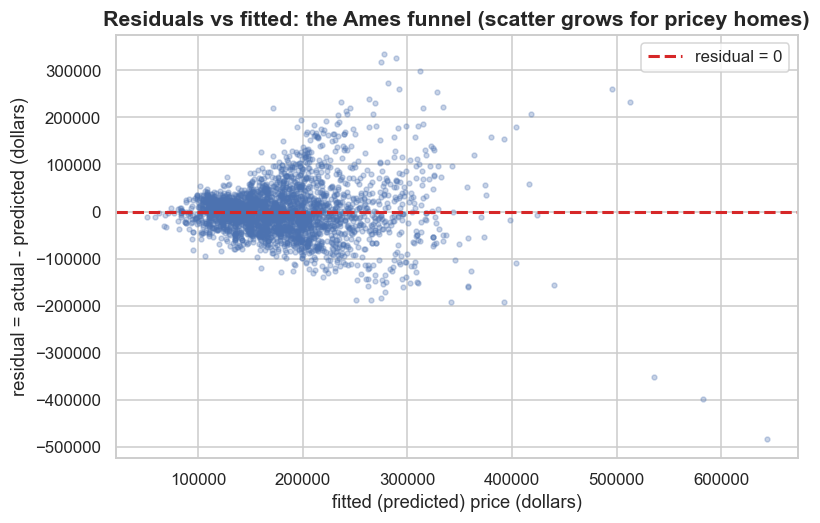

residual SD for the cheaper half :      30,763 dollars
residual SD for the pricier half :      73,801 dollars
-> the spread is about 2.4x larger for pricey homes: a funnel, NOT constant scatter.
   So the textbook SE(b) is a bit optimistic here -- the core lesson fixes this with a robust SE.


In [9]:
fig, ax = plt.subplots()
ax.scatter(yhat, resid, s=10, alpha=0.30, color='#4c72b0')
ax.axhline(0, color='#d62728', lw=2, ls='--', label='residual = 0')
ax.set_xlabel('fitted (predicted) price (dollars)')
ax.set_ylabel('residual = actual - predicted (dollars)')
ax.set_title('Residuals vs fitted: the Ames funnel (scatter grows for pricey homes)')
ax.legend(); plt.show()

# A crude one-line read of "constant spread?": compare the residual SD in the
# cheap half vs the pricey half of the fitted values.
mid = np.median(yhat)
sd_low  = resid[yhat <= mid].std(ddof=1)
sd_high = resid[yhat >  mid].std(ddof=1)
print(f'residual SD for the cheaper half : {sd_low:>11,.0f} dollars')
print(f'residual SD for the pricier half : {sd_high:>11,.0f} dollars')
print(f'-> the spread is about {sd_high/sd_low:.1f}x larger for pricey homes: a funnel, NOT constant scatter.')
print('   So the textbook SE(b) is a bit optimistic here -- the core lesson fixes this with a robust SE.')

The spread **grows** with price — the textbook constant-scatter assumption is bent, so the formula
$\text{SE}(b)$ runs a touch small (the core lesson shows a bootstrap and a robust HC3 standard error,
both wider and more honest). The good news: the slope itself is unchanged and still sits dozens of
standard errors from 0, so *whether* the relationship is real never came into doubt — only *how
precisely* we can pin the number down.

## 4) The idiom — vectorized residuals

Every quantity above leaned on **one vectorized expression**: `resid = y - (a + b * x)` computes all
2,930 residuals at once, with no loop. You *could* loop over the homes one at a time — same numbers, but
slower and noisier to read. Compare the two; the vectorized line is the idiom you want (and the one the
library uses under the hood).

In [10]:
# The loop way (how you might first think of it):
resid_loop = []
for xi, yi in zip(x, y):
    resid_loop.append(yi - (a + b * xi))
resid_loop = np.array(resid_loop)

# The vectorized way (what NumPy is for) — the whole column at once:
resid_vec = y - (a + b * x)

print('same residuals either way?', np.allclose(resid_loop, resid_vec))
print(f'first 3, loop      : {np.round(resid_loop[:3], 1)}')
print(f'first 3, vectorized: {np.round(resid_vec[:3], 1)}')

# And SE(b) is then just two more vectorized reductions over that column:
se_b_vec = np.sqrt((resid_vec**2).sum() / (n - 2)) / np.sqrt(((x - x.mean())**2).sum())
print(f'\nSE(b) rebuilt in one vectorized chain: {se_b_vec:.4f}   (matches earlier: {np.isclose(se_b_vec, se_b)})')
print('No loop anywhere -- residuals, the sum of squares, and SE(b) are all whole-array operations.')

same residuals either way? True
first 3, loop      : [16745.1 -8367.5 10269. ]
first 3, vectorized: [16745.1 -8367.5 10269. ]

SE(b) rebuilt in one vectorized chain: 2.0661   (matches earlier: True)
No loop anywhere -- residuals, the sum of squares, and SE(b) are all whole-array operations.


## 5) Refactor into a reusable function

You've now written the same chain — fit, residuals, $s_e$, $\text{SE}(b)$, $t$, $df$, $p$, CI — once. The
programmer's reflex is to **wrap repeated work in a function**: name it, give it inputs, `return` the
result. Then "is this slope real?" is one call you can reuse on *any* pair of numeric columns — a
different predictor, a different dataset entirely.

In [11]:
def slope_inference(x, y, conf=0.95):
    '''Inference for the slope of the least-squares line of y on x.

    Returns a dict with the slope, its standard error, the t-statistic for
    H0: slope = 0, the degrees of freedom, the two-sided p-value, and the
    lower/upper ends of a confidence interval.
    '''
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    dx = x - x.mean()
    slope = (dx * (y - y.mean())).sum() / (dx**2).sum()
    intercept = y.mean() - slope * x.mean()
    resid = y - (intercept + slope * x)
    se_resid = np.sqrt((resid**2).sum() / (n - 2))      # n-2: slope + intercept estimated
    se = se_resid / np.sqrt((dx**2).sum())              # SE of the slope
    t = slope / se
    df = n - 2
    p = 2 * stats.t.sf(abs(t), df)                      # two-sided
    tstar = stats.t.ppf(0.5 + conf / 2, df)
    return {
        'slope': slope, 'se': se, 't': t, 'df': df, 'p': p,
        'ci_low': slope - tstar * se, 'ci_high': slope + tstar * se,
    }

# Reuse it on our two columns, and re-check the key numbers against linregress:
res = slope_inference(ames['area'], ames['price'])
for k, v in res.items():
    print(f'  {k:8}: {v:,.6g}')

lr = stats.linregress(x, y)
print('\nmatches scipy.stats.linregress?')
print('  slope?', np.isclose(res['slope'], lr.slope))
print('  SE?   ', np.isclose(res['se'], lr.stderr))
print('  p?    ', np.isclose(res['p'], lr.pvalue))

  slope   : 111.694
  se      : 2.06607
  t       : 54.061
  df      : 2,928
  p       : 0
  ci_low  : 107.643
  ci_high : 115.745

matches scipy.stats.linregress?
  slope? True
  SE?    True
  p?     True


A function is a contract: *give me two columns, I'll give you the slope and everything you need to judge
whether it's real.* Once it's correct, you stop thinking about the formulas and start thinking in
**estimates and uncertainty** — exactly the leap from "writing statistics" to "doing statistics in code."
(And yes, `scipy.stats.linregress` and a `statsmodels` table exist; the point was to *build* the
inference so you know what they're doing — and to remember the diagnostic that tells you when to trust
them.)

## 6) Now you code

Write the code yourself. Add a new cell (the **+** button in the toolbar) and try each — predict the
answer before you run it.

1. **Rebuild the CI by hand from the pieces.** Using the `b`, `se_b` and `df` already in memory, write the
   two lines `tstar = stats.t.ppf(0.975, df)` and `b - tstar*se_b, b + tstar*se_b`. Confirm you get back
   the same `(107.6, 115.7)` interval — the table really is just $b \pm t^{*}\text{SE}(b)$.

2. **A 99% interval is wider.** Call `slope_inference(ames['area'], ames['price'], conf=0.99)` and compare
   its `ci_low`/`ci_high` to the 95% one. Is the 99% interval **wider** or narrower? (More confidence
   means a bigger $t^{*}$, so a wider net.)

3. **Where does the t-statistic's p-value come from?** Print `2 * stats.t.sf(abs(t_stat), df)` and compare
   it to `lr.pvalue`. Then try `stats.t.sf(54, df)` for a moderate t and for `t_stat` — see how fast the
   tail area collapses toward 0 as $t$ grows, which is why our p prints as essentially 0.

4. **A different predictor.** Overall quality is a strong one. Run
   `q = ames.dropna(subset=['Overall.Qual', 'price'])` then
   `print(slope_inference(q['Overall.Qual'], q['price']))`. Is its slope's p-value still tiny? Sanity-check
   your dict against `stats.linregress(q['Overall.Qual'], q['price'])`.

## What you learned

**Coding**
- Pull columns to NumPy arrays and do **vectorized** math: `resid = y - (a + b*x)` builds all 2,930
  residuals in one line, and $\text{SE}(b)$ is two more whole-array reductions — no loop, far faster.
- `scipy.stats` gives you the t-distribution directly: **`stats.t.sf(|t|, df)`** for an upper-tail area
  (double it for a two-sided p) and **`stats.t.ppf(0.975, df)`** for the $t^{*}$ multiplier.
- **`scipy.stats.linregress(x, y)`** returns `slope, intercept, rvalue, pvalue, stderr` in one call — and
  its `pvalue` *is* the two-sided slope t-test, so it's the perfect check on your from-scratch work
  (`np.isclose`).
- **Refactor repeated work into a function** with clear inputs and a `return` (here a dict), then reuse it
  on any pair of columns.

**Statistics (now demystified)**
- The **residual standard error** $s_e=\sqrt{\sum e_i^2/(n-2)}$ uses **$n-2$** because the slope *and*
  intercept were estimated; the **slope's SE** $=s_e/\sqrt{\sum (x_i-\bar{x})^2}$ uses that **sum** of
  squared deviations (not a variance) — get these two right and your $t$, $p$ and CI match the library.
- The **t-statistic** $t=b/\text{SE}(b)$ tests $H_0:\beta_1=0$; the **p-value** is the two-tailed t-area;
  the **95% CI** is $b\pm t^{*}\text{SE}(b)$ — you reproduced all of them and confirmed against
  `linregress`.
- A **residuals-vs-fitted** plot checks the constant-scatter assumption; the Ames **funnel**
  (heteroscedasticity) makes the textbook SE a little too small — *whether* the slope is real is never in
  doubt, but *how precisely* it's pinned down is.

**Back to the core lesson** ([Lesson 18: Correlation & regression: inference](18-regression-inference.ipynb))
for the *meaning* of these numbers, or read on through the course.

---

**↩ Back to the lesson:** [Lesson 18: Correlation & regression: inference](18-regression-inference.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset](18-regression-inference~another-dataset.ipynb)